# Example thermodynamic trajectories for NSM ejecta

Builds **5 distinct thermodynamic trajectories** for neutron-star-merger (NSM)
ejecta directly from a closed-form analytic model, instead of rescaling a
numerical reference trajectory. The model is the standard simplified picture
used for parametrized r-process trajectories when explicit hydrodynamic
temperature/density histories aren't used (e.g. Freiburghaus et al. 1999;
Rosswog 2005; Metzger 2010; Korobkin et al. 2012):

1. **Kinematics** - each fluid element accelerates away from the merger site
   over a characteristic timescale $t_\mathrm{acc}$ (tidal torques / shock
   passage / neutrino or viscous wind launching) and asymptotes to a terminal
   velocity $v_\infty$, i.e. homologous free expansion at late times.
2. **Density** from mass conservation for homologous, self-similar radial
   flow: $\rho \propto R^{-3}$.
3. **Temperature** from an adiabatic closure along the expansion: $T_9
   \propto \rho^{1/3}$ (the radiation/relativistic-particle-dominated
   adiabatic index) - equivalent to the familiar $T \propto 1/R$ scaling of a
   homologously expanding, radiation-dominated gas.
4. **$Y_e$** held fixed per trajectory (frozen composition; no explicit
   neutrino/weak-reaction coupling in this simplified model).

Initial conditions ($Y_e$, $\rho_0$, $T_{9,0}$, $R_0$, $v_\infty$,
$t_\mathrm{acc}$) are chosen per trajectory to represent 5 physically
distinct ejecta components spanning the range seen in NSM merger simulations,
from fast, low-$Y_e$ dynamical ejecta to slow, high-$Y_e$ disk-wind ejecta.

Output files follow the trajectory format used across this repo:

```
time[s]   T9[GK]   density[g/cm^3]   R[km]   Ye
```


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Analytic trajectory model

$v(t) = v_\infty \tanh(t / t_\mathrm{acc})$ integrates in closed form to

$$R(t) = R_0 + v_\infty t_\mathrm{acc} \ln\cosh(t / t_\mathrm{acc})$$

which starts at rest ($R=R_0$, $v=0$ at $t=0$) and asymptotes to linear,
homologous growth at $v_\infty$ once $t \gg t_\mathrm{acc}$ - i.e. the
early hydrodynamic acceleration phase seen in merger simulations, followed by
free-streaming ejecta. `log_cosh` is written in its numerically stable form
since $t / t_\mathrm{acc}$ spans up to ${\sim}10^{11}$ for these
trajectories (plain `np.cosh` would overflow).

Density and temperature then follow directly from $R(t)$:

$$\rho(t) = \rho_0 \left(\frac{R_0}{R(t)}\right)^3 \qquad\qquad
T_9(t) = T_{9,0} \left(\frac{\rho(t)}{\rho_0}\right)^{\alpha}$$

with $\alpha = 1/3$ by default.

In [2]:
C_LIGHT_KM_S = 2.998e5          # km/s
ADIABATIC_INDEX = 1.0 / 3.0     # T9 ~ density**ADIABATIC_INDEX along the adiabat

T_MIN, T_MAX, N_TIME = 1e-6, 1.0e8, 500   # seconds
# Spans the prompt-ejection phase through late-time radioactive decay,
# matching the duration of the WinNet runs in Runs/ (mainout.dat reaches
# ~4.3e7 s) and the heating-rate window used in Heating_rates.ipynb (<=500 d).
time = np.logspace(np.log10(T_MIN), np.log10(T_MAX), N_TIME)


def log_cosh(x):
    """Numerically stable log(cosh(x)); avoids overflow in np.cosh for large x."""
    x = np.abs(x)
    return x - np.log(2.0) + np.log1p(np.exp(-2.0 * x))


def build_trajectory(time, Ye, rho0, T9_0, R0, v_inf_c, t_acc, alpha=ADIABATIC_INDEX):
    """Analytic homologous-expansion + adiabatic-cooling trajectory.

    Returns R(t) [km], density(t) [g/cm^3], T9(t) [GK], Ye(t) (constant).
    """
    v_inf = v_inf_c * C_LIGHT_KM_S
    R = R0 + v_inf * t_acc * log_cosh(time / t_acc)
    density = rho0 * (R0 / R) ** 3
    T9 = T9_0 * (density / rho0) ** alpha
    Ye_arr = np.full_like(time, Ye)
    return R, density, T9, Ye_arr

## 2. Define 5 trajectories spanning the ejecta parameter space

Each row is a distinct physical scenario, ordered from fast/low-$Y_e$ to
slow/high-$Y_e$ ejecta: a low-$Y_e$ tidal tail, shock-heated dynamical
ejecta, an intermediate case, a neutrino-driven wind, and a high-$Y_e$ disk
wind. Velocities and acceleration timescales follow the same trend seen in
simulations: dynamical ejecta is prompt (${\sim}1$-$5$ ms ramp-up) and fast
(${\sim}0.1$-$0.2c$); wind ejecta is driven over a longer timescale
(${\sim}$tens of ms) and is slower (${\lesssim}0.05c$).

In [3]:
TRAJECTORIES = [
    # label                                  Ye     rho0        T9_0   R0      v_inf   t_acc
    #                                                [g/cm^3]    [GK]   [km]    [c]     [s]
    {"label": "Dynamical - tidal tail (low Ye)", "Ye": 0.05, "rho0": 3.0e13, "T9_0": 11.0, "R0": 30.0,  "v_inf_c": 0.20, "t_acc": 1.0e-3},
    {"label": "Dynamical - shock-heated",        "Ye": 0.15, "rho0": 1.5e13, "T9_0": 9.0,  "R0": 40.0,  "v_inf_c": 0.15, "t_acc": 2.0e-3},
    {"label": "Intermediate ejecta",             "Ye": 0.25, "rho0": 6.0e12, "T9_0": 7.0,  "R0": 55.0,  "v_inf_c": 0.10, "t_acc": 5.0e-3},
    {"label": "Neutrino-driven wind",            "Ye": 0.35, "rho0": 1.5e12, "T9_0": 5.0,  "R0": 80.0,  "v_inf_c": 0.05, "t_acc": 1.5e-2},
    {"label": "High-Ye disk wind",               "Ye": 0.45, "rho0": 3.0e11, "T9_0": 3.5,  "R0": 120.0, "v_inf_c": 0.02, "t_acc": 4.0e-2},
]

pd.DataFrame(TRAJECTORIES)

,label,Ye,rho0,T9_0,R0,v_inf_c,t_acc
0,Dynamical - tidal tail (low Ye),0.05,3.000000e+13,11.0,30.0,0.20,0.001
1,Dynamical - shock-heated,0.15,1.500000e+13,9.0,40.0,0.15,0.002
2,Intermediate ejecta,0.25,6.000000e+12,7.0,55.0,0.10,0.005
3,Neutrino-driven wind,0.35,1.500000e+12,5.0,80.0,0.05,0.015
4,High-Ye disk wind,0.45,3.000000e+11,3.5,120.0,0.02,0.040


## 3. Generate and write the trajectory files

Evaluate `build_trajectory` on the common time grid for each scenario and
write it out in the same 5-column format read elsewhere in this repo.

In [4]:
OUTPUT_DIR = "Data/Trajectories_example"
HEADER = "# time[s], T9[GK], density[g/cm^3], R[km], Ye"

os.makedirs(OUTPUT_DIR, exist_ok=True)

log_rows = []
for idx, traj in enumerate(TRAJECTORIES, start=1):
    R, density, T9, Ye_arr = build_trajectory(
        time, traj["Ye"], traj["rho0"], traj["T9_0"], traj["R0"],
        traj["v_inf_c"], traj["t_acc"],
    )

    fname = f"traj{idx:04d}.dat"
    outpath = os.path.join(OUTPUT_DIR, fname)
    with open(outpath, "w") as f:
        f.write(HEADER + "\n\n")
        for t, T9_, dens, r, ye in zip(time, T9, density, R, Ye_arr):
            f.write(f"{t:.4e} {T9_:.4e} {dens:.4e} {r:.4e} {ye:.5f}\n")

    log_rows.append({
        "file": fname,
        "label": traj["label"],
        "Ye": traj["Ye"],
        "T9_0_GK": traj["T9_0"],
        "rho0_g_cm3": traj["rho0"],
        "R0_km": traj["R0"],
        "v_inf_c": traj["v_inf_c"],
        "v_inf_km_s": traj["v_inf_c"] * C_LIGHT_KM_S,
        "t_acc_s": traj["t_acc"],
    })
    print(f"Wrote {outpath}  ({traj['label']})")

Wrote Data/Trajectories_example/traj0001.dat  (Dynamical - tidal tail (low Ye))
Wrote Data/Trajectories_example/traj0002.dat  (Dynamical - shock-heated)
Wrote Data/Trajectories_example/traj0003.dat  (Intermediate ejecta)
Wrote Data/Trajectories_example/traj0004.dat  (Neutrino-driven wind)
Wrote Data/Trajectories_example/traj0005.dat  (High-Ye disk wind)


In [5]:
# Lookup table so the parameters behind each file stay traceable
index_df = pd.DataFrame(log_rows)
index_path = os.path.join(OUTPUT_DIR, "trajectories_index.csv")
index_df.to_csv(index_path, index=False, float_format="%.6g")

print(f"Wrote index file to {index_path}")
index_df

Wrote index file to Data/Trajectories_example/trajectories_index.csv


,file,label,Ye,T9_0_GK,rho0_g_cm3,R0_km,v_inf_c,v_inf_km_s,t_acc_s
0,traj0001.dat,Dynamical - tidal tail (low Ye),0.05,11.0,3.000000e+13,30.0,0.20,59960.0,0.001
1,traj0002.dat,Dynamical - shock-heated,0.15,9.0,1.500000e+13,40.0,0.15,44970.0,0.002
2,traj0003.dat,Intermediate ejecta,0.25,7.0,6.000000e+12,55.0,0.10,29980.0,0.005
3,traj0004.dat,Neutrino-driven wind,0.35,5.0,1.500000e+12,80.0,0.05,14990.0,0.015
4,traj0005.dat,High-Ye disk wind,0.45,3.5,3.000000e+11,120.0,0.02,5996.0,0.040


## 4. Read back and plot the 5 trajectories

Reload each file with the same `read_trajectory` helper used in
`Read_trajectories.ipynb`, then compare $T_9(t)$, $\rho(t)$, $R(t)$ and
$Y_e(t)$ across the 5 scenarios. All panels share a log time axis, since the
trajectories now span from microseconds to years.

In [6]:
def read_trajectory(filepath):
    data = np.genfromtxt(filepath, comments="#")
    return {
        "time": data[:, 0],
        "T9": data[:, 1],
        "density": data[:, 2],
        "R": data[:, 3],
        "Ye": data[:, 4],
        "name": os.path.splitext(os.path.basename(filepath))[0],
    }


trajs = [read_trajectory(os.path.join(OUTPUT_DIR, row["file"])) for row in log_rows]

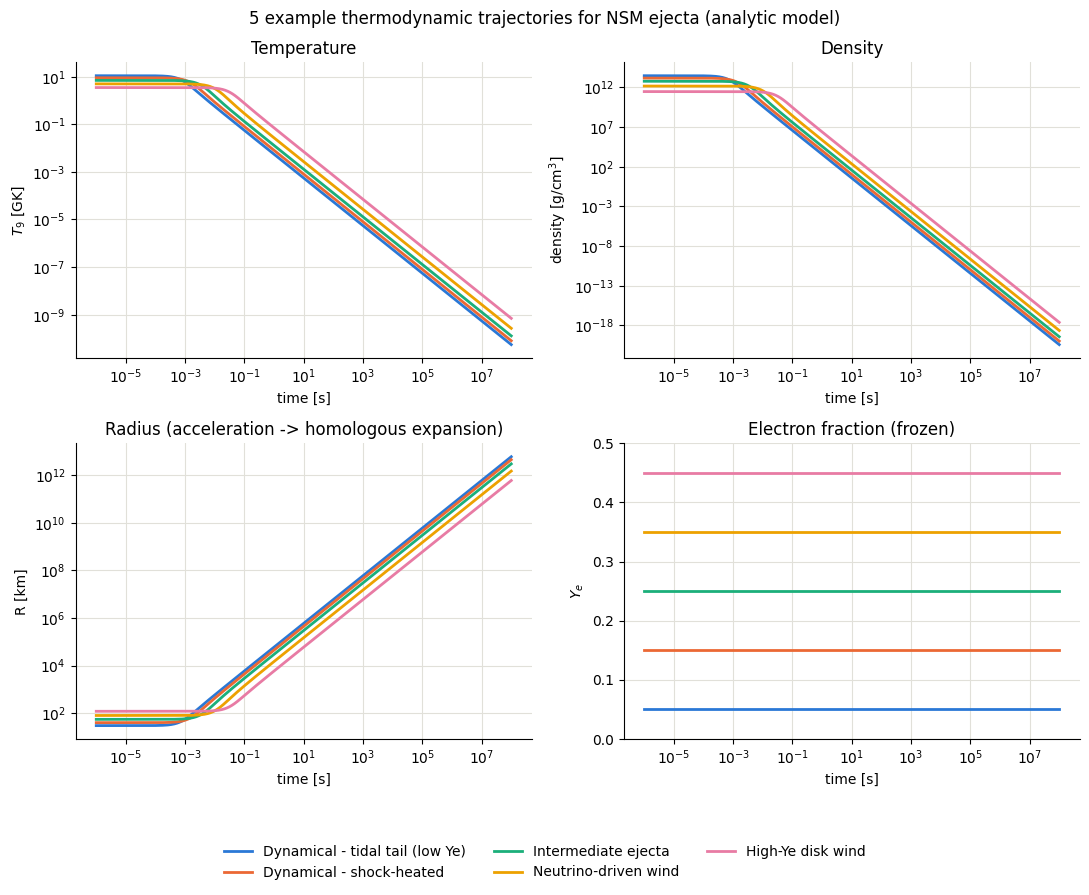

In [7]:
# Fixed categorical order (blue, orange, aqua, yellow, magenta) -> same slot
# always means the same trajectory, consistent with crear_trajectorias.ipynb.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
GRID_COLOR = "#e1e0d9"

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
for color, traj, row in zip(CATEGORICAL, trajs, log_rows):
    ax.plot(traj["time"], traj["T9"], color=color, lw=2, label=row["label"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$T_9$ [GK]")
ax.set_title("Temperature")

ax = axes[0, 1]
for color, traj, row in zip(CATEGORICAL, trajs, log_rows):
    ax.plot(traj["time"], traj["density"], color=color, lw=2, label=row["label"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"density [g/cm$^3$]")
ax.set_title("Density")

ax = axes[1, 0]
for color, traj, row in zip(CATEGORICAL, trajs, log_rows):
    ax.plot(traj["time"], traj["R"], color=color, lw=2, label=row["label"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("time [s]")
ax.set_ylabel("R [km]")
ax.set_title("Radius (acceleration -> homologous expansion)")

ax = axes[1, 1]
for color, traj, row in zip(CATEGORICAL, trajs, log_rows):
    ax.plot(traj["time"], traj["Ye"], color=color, lw=2, label=row["label"])
ax.set_xscale("log")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$Y_e$")
ax.set_ylim(0, 0.5)
ax.set_title("Electron fraction (frozen)")

for ax in axes.flat:
    ax.grid(True, color=GRID_COLOR, lw=0.8, which="both")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0.0))
fig.suptitle("5 example thermodynamic trajectories for NSM ejecta (analytic model)")
fig.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

## Output

- 5 trajectory files: `Data/Trajectories_example/traj0001.dat` ... `traj0005.dat`
- Parameter lookup table: `Data/Trajectories_example/trajectories_index.csv`

Each `.dat` file has the same 5-column format (`time[s] T9[GK] density[g/cm^3]
R[km] Ye`) as the trajectories elsewhere in this repo, so it can be fed
directly into the same downstream tools (e.g. WinNet runs, heating-rate
calculations).

**Model limitations to keep in mind:** the electron fraction is frozen (no
neutrino absorption/emission changing $Y_e$ during expansion), a single
power-law adiabatic index couples $T_9$ to $\rho$ everywhere (real EOS
behavior varies with degeneracy and composition, especially at the higher
densities), and there is no explicit NSE/nuclear-reaction feedback on the
thermodynamics. This is a lightweight stand-in for a real hydrodynamic
trajectory - good for examples/tests, not a substitute for simulation output
when precise nucleosynthesis yields matter.